In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.16.1


In [2]:
import numpy as np

print("NumPy version:", np.__version__)


NumPy version: 1.26.4


In [3]:
import matplotlib.pylab as plt
print("Matplotlib version:", plt.__version__)

Matplotlib version: 1.26.4


In [13]:
### Prepare training  validation & test  dataset
import os
folder = '/kaggle/input/datasets/ummershakeel/rice-diseases'
data_dir = os.path.join(os.path.dirname(folder), '/kaggle/input/datasets/ummershakeel/rice-diseases')
train_dir = os.path.join(data_dir, 'train')
validation_dir = os.path.join(data_dir, 'validation')
test_dir = os.path.join(data_dir, 'test')




In [14]:
import time
import os
from os.path import exists

def count(dir, counter=0):
    "returns number of files in dir and subdirs"
    for pack in os.walk(dir):
        for f in pack[2]:
            counter += 1
    return dir + " : " + str(counter) + "files"


In [15]:
print('total images for training :', count(train_dir))
print('total images for validation :', count(validation_dir))
print('total images for test :', count(test_dir))



total images for training : /kaggle/input/datasets/ummershakeel/rice-diseases/train : 1338files
total images for validation : /kaggle/input/datasets/ummershakeel/rice-diseases/validation : 384files
total images for test : /kaggle/input/datasets/ummershakeel/rice-diseases/test : 192files


In [16]:
import os

def create_label_mapping(directory):
    label_mapping = {}
    for idx, label in enumerate(os.listdir(directory)):
        label_mapping[label] = idx
    return label_mapping

# Assuming 'train_dir', 'validation_dir', and 'test_dir' are already defined
train_label_mapping = create_label_mapping(train_dir)
validation_label_mapping = create_label_mapping(validation_dir)
test_label_mapping = create_label_mapping(test_dir)

print('Label mapping for training:', train_label_mapping)
print('Label mapping for validation:', validation_label_mapping)
print('Label mapping for test:', test_label_mapping)


Label mapping for training: {'Leaf Blast': 0, 'Brown spot': 1, 'Bacterial leaf blight': 2}
Label mapping for validation: {'Leaf Blast': 0, 'Brown spot': 1, 'Bacterial leaf blight': 2}
Label mapping for test: {'Leaf Blast': 0, 'Brown spot': 1, 'Bacterial leaf blight': 2}


In [19]:
# =========================
# CELL 1: Imports & Setup
# =========================
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import ModelCheckpoint, Callback

# =========================
# CELL 2: Directories & Parameters
# =========================
base_folder = '/kaggle/input/datasets/ummershakeel/rice-diseases'
train_dir = os.path.join(base_folder, 'train')
validation_dir = os.path.join(base_folder, 'validation')
test_dir = os.path.join(base_folder, 'test')

# Hyperparameters
img_width, img_height = 224, 224  # MobileNetV2 standard input
batch_size = 32
num_classes = 3
lr = 0.001
epochs = 30

# =========================
# CELL 3: Callbacks
# =========================
class TimeHistory(Callback):
    def on_train_begin(self, logs=None):
        self.times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        self.times.append(time.time() - self.epoch_start_time)

time_callback = TimeHistory()
total_start_time = time.time()

checkpoint_cb = ModelCheckpoint('best_mobilenetv2.keras', save_best_only=True, monitor='val_accuracy', mode='max')

# =========================
# CELL 4: Data Generators
# =========================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_test_datagen.flow_from_directory(
    validation_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Check if generators have images
if train_generator.samples == 0 or validation_generator.samples == 0:
    raise ValueError("Training or validation directory is empty! Check paths and images.")

# =========================
# CELL 5: Model Setup
# =========================
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=SGD(learning_rate=lr, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================
# CELL 6: Train Model
# =========================
# ✅ Let Keras handle steps automatically
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    callbacks=[time_callback, checkpoint_cb],
    verbose=1
)

total_training_time = time.time() - total_start_time
average_epoch_time = total_training_time / epochs
print(f"Total Training Time: {total_training_time:.2f}s, Average Epoch Time: {average_epoch_time:.2f}s")

Found 1338 images belonging to 3 classes.
Found 384 images belonging to 3 classes.
Found 192 images belonging to 3 classes.


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 38s 700ms/step - accuracy: 0.5749 - loss: 0.9729 - val_accuracy: 0.8854 - val_loss: 0.3796
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 29s 588ms/step - accuracy: 0.8600 - loss: 0.4205 - val_accuracy: 0.9375 - val_loss: 0.2677
Epoch 3/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 30s 606ms/step - accuracy: 0.9077 - loss: 0.2792 - val_accuracy: 0.9453 - val_loss: 0.2213
Epoch 4/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 30s 623ms/step - accuracy: 0.9437 - loss: 0.2222 - val_accuracy: 0.9531 - val_loss: 0.1884
Epoch 5/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 33s 667ms/step - accuracy: 0.9368 - loss: 0.2266 - val_accuracy: 0.9583 - val_loss: 0.1742
Epoch 6/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 30s 608ms/step - accuracy: 0.9493 - loss: 0.1858 - val_accuracy: 0.9609 - val_loss: 0.1556
Epoch 7/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 31s 666ms/step - accuracy: 0.9513 - loss: 0.1887 - val_accuracy: 0.9635 - val_loss: 0.1454
Epoch 8/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 30s 627ms/step - accuracy: 0.9639 - loss: 0.1501 - val_accu

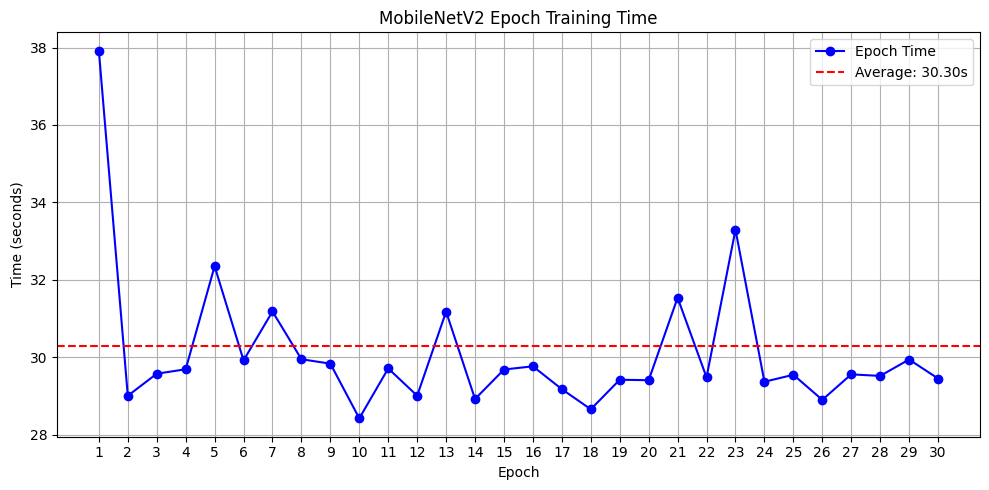

Total Training Time: 15.15 minutes
Average Epoch Time: 30.30 seconds


In [20]:
# =========================
# CELL 7: Epoch Time Plot for MobileNetV2 (Saved at 500 dpi)
# =========================
import matplotlib.pyplot as plt

# Ensure time_callback.times is available
if not hasattr(time_callback, 'times') or len(time_callback.times) != epochs:
    raise ValueError("time_callback.times must contain one entry per epoch")

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), time_callback.times, 'b-o', label='Epoch Time')

# Plot average epoch time
plt.axhline(
    y=average_epoch_time,
    color='r',
    linestyle='--',
    label=f'Average: {average_epoch_time:.2f}s'
)

plt.xlabel('Epoch')
plt.ylabel('Time (seconds)')
plt.title('MobileNetV2 Epoch Training Time')

plt.xticks(range(1, epochs + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()

# =========================
# Save figure at 500 dpi
# =========================
plt.savefig("MobileNetV2_Epoch_Training_Time.png", dpi=500, bbox_inches='tight')
plt.show()

# =========================
# Print training summary
# =========================
print(f"Total Training Time: {total_training_time/60:.2f} minutes")
print(f"Average Epoch Time: {average_epoch_time:.2f} seconds")

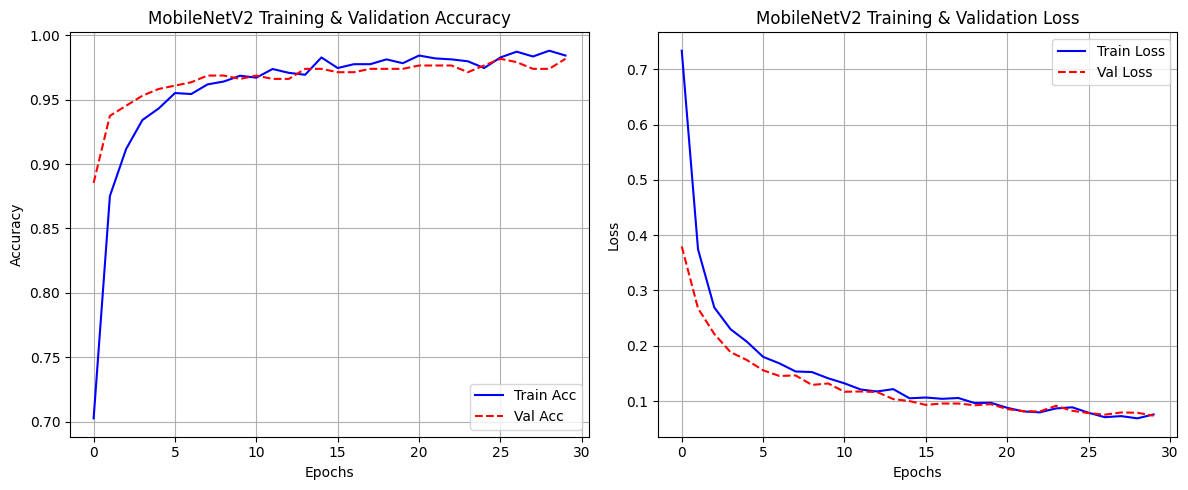

In [21]:
# =========================
# CELL 8: Accuracy & Loss Plot for MobileNetV2 (Saved at 500 dpi)
# =========================
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], 'b-', label='Train Acc')
plt.plot(history.history['val_accuracy'], 'r--', label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('MobileNetV2 Training & Validation Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], 'b-', label='Train Loss')
plt.plot(history.history['val_loss'], 'r--', label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('MobileNetV2 Training & Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()

# =========================
# Save figure at 500 dpi
# =========================
plt.savefig("MobileNetV2_Accuracy_Loss.png", dpi=500, bbox_inches='tight')

plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 393ms/step


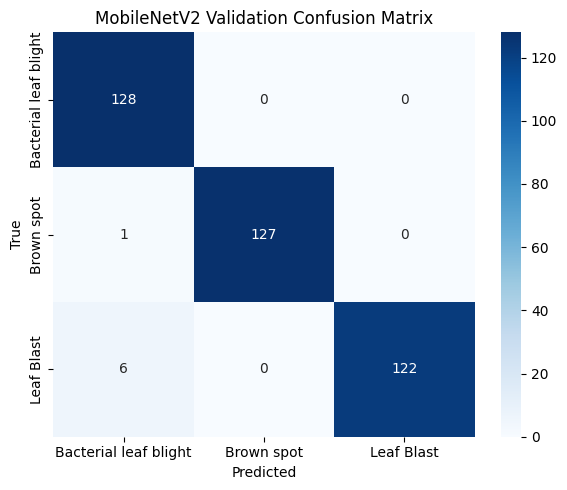

                       precision    recall  f1-score   support

Bacterial leaf blight       0.95      1.00      0.97       128
           Brown spot       1.00      0.99      1.00       128
           Leaf Blast       1.00      0.95      0.98       128

             accuracy                           0.98       384
            macro avg       0.98      0.98      0.98       384
         weighted avg       0.98      0.98      0.98       384



In [22]:
# =========================
# CELL 9: Confusion Matrix (Validation) - MobileNetV2 - Save at 500 dpi
# =========================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

validation_generator.reset()

val_preds = model.predict(validation_generator, steps=len(validation_generator), verbose=1)
val_pred_labels = np.argmax(val_preds, axis=1)
val_true_labels = validation_generator.classes

cm_val = confusion_matrix(val_true_labels, val_pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_val,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=validation_generator.class_indices.keys(),
    yticklabels=validation_generator.class_indices.keys()
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('MobileNetV2 Validation Confusion Matrix')
plt.tight_layout()

# =========================
# Save figure at 500 dpi
# =========================
plt.savefig("MobileNetV2_Confusion_Matrix_Validation.png", dpi=500, bbox_inches='tight')

plt.show()

# =========================
# Classification Report
# =========================
print(classification_report(
    val_true_labels,
    val_pred_labels,
    target_names=list(validation_generator.class_indices.keys())
))

1/6 ━━━━━━━━━━━━━━━━━━━━ 1s 202ms/step

/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 424ms/step


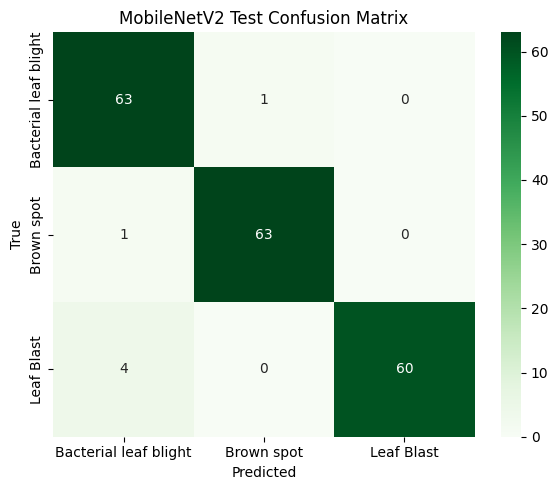

                       precision    recall  f1-score   support

Bacterial leaf blight       0.93      0.98      0.95        64
           Brown spot       0.98      0.98      0.98        64
           Leaf Blast       1.00      0.94      0.97        64

             accuracy                           0.97       192
            macro avg       0.97      0.97      0.97       192
         weighted avg       0.97      0.97      0.97       192



In [23]:
# =========================
# CELL 10: Confusion Matrix (Test) - MobileNetV2 - Save at 500 dpi
# =========================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

test_generator.reset()

test_preds = model.predict(test_generator, steps=len(test_generator), verbose=1)
test_pred_labels = np.argmax(test_preds, axis=1)
test_true_labels = test_generator.classes

cm_test = confusion_matrix(test_true_labels, test_pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=test_generator.class_indices.keys(),
    yticklabels=test_generator.class_indices.keys()
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('MobileNetV2 Test Confusion Matrix')
plt.tight_layout()

# =========================
# Save figure at 500 dpi
# =========================
plt.savefig("MobileNetV2_Confusion_Matrix_Test.png", dpi=500, bbox_inches='tight')

plt.show()

# =========================
# Classification Report
# =========================
print(classification_report(
    test_true_labels,
    test_pred_labels,
    target_names=list(test_generator.class_indices.keys())
))

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 365ms/step


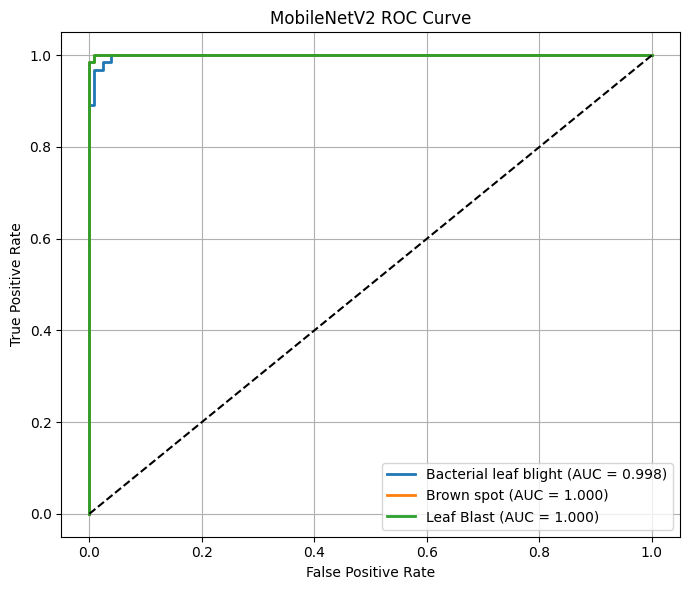

In [24]:
# =========================
# CELL 11: ROC Curve (Test Set) - MobileNetV2 - Save at 500 dpi
# =========================
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# True labels
y_true = test_generator.classes

# Predicted probabilities
y_score = model.predict(test_generator, verbose=1)

# Binarize labels
n_classes = num_classes
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# =========================
# Plot ROC Curves
# =========================
plt.figure(figsize=(7,6))

class_names = list(test_generator.class_indices.keys())

for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        lw=2,
        label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})'
    )

# Random guess line
plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MobileNetV2 ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()

# =========================
# Save ROC figure
# =========================
plt.savefig("MobileNetV2_ROC_Curve.png", dpi=500, bbox_inches='tight')

plt.show()

In [26]:
import cv2
import numpy as np
import os
import random
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import shutil
from pathlib import Path

# =========================
# CONFIG
# =========================
IMAGE_SIZE = (224, 224)

test_dir = '/kaggle/input/datasets/ummershakeel/rice-diseases/test'
RESULT_DIR = '/kaggle/working/results'
ZIP_NAME = '/kaggle/working/result'

os.makedirs(RESULT_DIR, exist_ok=True)

# =========================
# Load Model
# =========================
model = load_model('/kaggle/working/best_mobilenetv2.keras')

classes = ['Bacterial leaf blight', 'Brown spot', 'Leaf Blast']

# =========================
# Data Generator
# =========================
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# =========================
# Load Image
# =========================
def load_image(filename):

    full_path = os.path.join(test_dir, filename)

    img = cv2.imread(full_path)

    if img is None:
        raise FileNotFoundError(f"Could not read image at path: {full_path}")

    img_resized = cv2.resize(img, IMAGE_SIZE)
    img_preprocessed = preprocess_input(img_resized.astype(np.float32))

    return img_resized, img_preprocessed


# =========================
# Predict
# =========================
def predict(image):

    probs = model.predict(np.asarray([image]), verbose=0)[0]
    idx = np.argmax(probs)

    return classes[idx], probs[idx]


# =========================
# GrabCut Segmentation
# =========================
def apply_grabcut(image):

    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = np.zeros(rgb.shape[:2], np.uint8)

    bgd_model = np.zeros((1,65), np.float64)
    fgd_model = np.zeros((1,65), np.float64)

    h, w = rgb.shape[:2]

    rect = (10,10,w-20,h-20)

    cv2.grabCut(rgb, mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)

    foreground_mask = np.where(
        (mask==cv2.GC_FGD) | (mask==cv2.GC_PR_FGD),
        1,0
    ).astype('uint8')

    return foreground_mask, rgb


# =========================
# Disease Segmentation
# =========================
def visualize_segmentation(foreground_mask, rgb):

    output = rgb.copy()

    leaf_contours,_ = cv2.findContours(
        foreground_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    cv2.drawContours(output, leaf_contours, -1, (255,0,0), 3)

    segmented = rgb.copy()
    segmented[foreground_mask==0] = 0

    hsv = cv2.cvtColor(segmented, cv2.COLOR_RGB2HSV)

    lower1 = np.array([10,40,40])
    upper1 = np.array([35,255,255])
    mask1 = cv2.inRange(hsv, lower1, upper1)

    lower2 = np.array([0,0,180])
    upper2 = np.array([180,60,255])
    mask2 = cv2.inRange(hsv, lower2, upper2)

    disease_mask = cv2.bitwise_or(mask1, mask2)

    kernel = np.ones((5,5), np.uint8)

    disease_mask = cv2.morphologyEx(disease_mask, cv2.MORPH_CLOSE, kernel)
    disease_mask = cv2.morphologyEx(disease_mask, cv2.MORPH_OPEN, kernel)

    disease_contours,_ = cv2.findContours(
        disease_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    overlay = output.copy()

    alpha = 0.4

    for cnt in disease_contours:

        if cv2.contourArea(cnt) > 500:
            cv2.drawContours(overlay, [cnt], -1, (0,255,255), -1)

    final_output = cv2.addWeighted(overlay, alpha, output, 1-alpha, 0)

    return final_output


# =========================
# Generate & Save Results
# =========================
print("🔄 Processing images and saving results...")

for i, filename in enumerate(random.sample(test_generator.filenames, 50), 1):

    print(f"\nProcessing {i}/50: {filename}")
    print(f"Source: {os.path.split(filename)[0]} | File: {filename}")

    try:

        original_img, img_preprocessed = load_image(filename)

        pred_class, conf = predict(img_preprocessed)

        foreground_mask, rgb = apply_grabcut(original_img)

        final_output = visualize_segmentation(foreground_mask, rgb)

        plt.figure(figsize=(12,6))

        plt.subplot(1,2,1)
        plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
        plt.title(f"Original Image\nSource: {os.path.split(filename)[0]}")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.imshow(final_output)
        plt.title(f"MobileNetV2 Model\nClass: {pred_class}\nConfidence: {conf:.2f}")
        plt.axis("off")

        plt.tight_layout()

        save_path = os.path.join(RESULT_DIR, f"result_{i}.png")

        plt.savefig(save_path, dpi=500, bbox_inches='tight')
        plt.close()

        print(f"  ✅ Saved: result_{i}.png | Prediction: {pred_class} ({conf:.2f})")

    except Exception as e:

        print(f"  ❌ Error: {e}")
        continue


# =========================
# ZIP Results
# =========================
print("\n📦 Creating ZIP archive...")

shutil.make_archive(ZIP_NAME, 'zip', RESULT_DIR)

print("\n"+"="*50)
print("✅ PROCESSING COMPLETE!")
print("="*50)
print(f"📍 Results saved in: {RESULT_DIR}/")
print(f"📍 50 high-resolution images saved at 500 DPI")
print(f"📍 ZIP file created: {ZIP_NAME}.zip")
print("📥 Ready for download!")
print("="*50)

Found 192 images belonging to 3 classes.
🔄 Processing images and saving results...

Processing 1/50: Bacterial leaf blight/Bacterial leaf blight_original_BACTERIALBLIGHT2_103.jpg_467f9b9f-7754-451a-9ee9-b8cd21648e8f.PNG
Source: Bacterial leaf blight | File: Bacterial leaf blight/Bacterial leaf blight_original_BACTERIALBLIGHT2_103.jpg_467f9b9f-7754-451a-9ee9-b8cd21648e8f.PNG
  ✅ Saved: result_1.png | Prediction: Bacterial leaf blight (0.88)

Processing 2/50: Brown spot/Brown spot_original_brownspot_rotated_067.jpg_a69cee6e-48a1-4407-bec0-65c0c7f2f4ef.PNG
Source: Brown spot | File: Brown spot/Brown spot_original_brownspot_rotated_067.jpg_a69cee6e-48a1-4407-bec0-65c0c7f2f4ef.PNG
  ✅ Saved: result_2.png | Prediction: Brown spot (1.00)

Processing 3/50: Leaf Blast/Leaf Blast_original_BLAST4_114.jpg_fbe89cfe-e90d-40e7-bf02-2ce41b3ee89e.PNG
Source: Leaf Blast | File: Leaf Blast/Leaf Blast_original_BLAST4_114.jpg_fbe89cfe-e90d-40e7-bf02-2ce41b3ee89e.PNG
  ✅ Saved: result_3.png | Prediction: Le